In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [67]:
from pathlib import Path
import sys

# Add the project's src directory to Python's import path
PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_PATH))

from parse_reviews import parse_reviews

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Reviews.csv"

df = parse_reviews(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 568,454
Columns: 8


In [68]:
df.head()

,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1/1,5.0,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0/0,1.0,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1/1,4.0,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,B000UA0QIQ,A395BORC6FGVXV,Karl,3/3,2.0,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0/0,5.0,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [69]:
df.info

<bound method DataFrame.info of        product/productId   review/userId               review/profileName  \
0             B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1             B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2             B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3             B000UA0QIQ  A395BORC6FGVXV                             Karl   
4             B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   
...                  ...             ...                              ...   
568449        B001EO7N10  A28KG5XORO54AY                 Lettie D. Carter   
568450        B003S1WTCU  A3I8AFVPEE8KI5                        R. Sawyer   
568451        B004I613EE  A121AA1GQV751Z                    pksd "pk_007"   
568452        B004I613EE   A3IBEVCTXKNOH          Kathy A. Welch "katwel"   
568453        B001LR2CU2  A3LGQPJCZVL9UC                         srfell17   

       review/helpfulness review/score revi

In [70]:
missing_values = df.isna().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing %": (missing_values / len(df) * 100).round(2)
})

missing_summary.sort_values("Missing Values", ascending=False)

,Missing Values,Missing %
product/productId,0,0.0
review/userId,0,0.0
review/profileName,0,0.0
review/helpfulness,0,0.0
review/score,0,0.0
review/time,0,0.0
review/summary,0,0.0
review/text,0,0.0


In [71]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 281
Duplicate percentage: 0.05%


In [72]:
print(df.dtypes)

product/productId     str
review/userId         str
review/profileName    str
review/helpfulness    str
review/score          str
review/time           str
review/summary        str
review/text           str
dtype: object


In [73]:
# Create a working copy for analysis
df_clean = df.copy()

# Convert review score to numeric
df_clean["review/score"] = pd.to_numeric(
    df_clean["review/score"],
    errors="coerce"
)

# Convert Unix timestamp to datetime
df_clean["review/time"] = pd.to_datetime(
    pd.to_numeric(df_clean["review/time"], errors="coerce"),
    unit="s"
)

# Split helpfulness into helpful votes and total votes
helpfulness_split = df_clean["review/helpfulness"].str.split("/", expand=True)

df_clean["helpful_votes"] = pd.to_numeric(
    helpfulness_split[0],
    errors="coerce"
)

df_clean["total_votes"] = pd.to_numeric(
    helpfulness_split[1],
    errors="coerce"
)

print("Data type conversion completed.")

Data type conversion completed.


In [74]:
df_clean[
    [
        "review/score",
        "review/time",
        "review/helpfulness",
        "helpful_votes",
        "total_votes"
    ]
].head(10)

,review/score,review/time,review/helpfulness,helpful_votes,total_votes
0,5.0,2011-04-27,1/1,1,1
1,1.0,2012-09-07,0/0,0,0
2,4.0,2008-08-18,1/1,1,1
3,2.0,2011-06-13,3/3,3,3
4,5.0,2012-10-21,0/0,0,0
5,4.0,2012-07-12,0/0,0,0
6,5.0,2012-06-20,0/0,0,0
7,5.0,2012-05-03,0/0,0,0
8,5.0,2011-11-23,1/1,1,1
9,5.0,2012-10-26,0/0,0,0


In [75]:
df_clean.dtypes

product/productId               str
review/userId                   str
review/profileName              str
review/helpfulness              str
review/score                float64
review/time           datetime64[s]
review/summary                  str
review/text                     str
helpful_votes                 int64
total_votes                   int64
dtype: object

In [76]:
print("Unique rating values:")
print(sorted(df_clean["review/score"].unique()))

print("\nRating range:")
print(f"Minimum: {df_clean['review/score'].min()}")
print(f"Maximum: {df_clean['review/score'].max()}")

invalid_scores = df_clean[
    (df_clean["review/score"] < 1) |
    (df_clean["review/score"] > 5)
]

print(f"\nInvalid ratings: {len(invalid_scores):,}")

Unique rating values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

Rating range:
Minimum: 1.0
Maximum: 5.0

Invalid ratings: 0


In [77]:
invalid_helpfulness = df_clean[
    (df_clean["helpful_votes"] < 0) |
    (df_clean["total_votes"] < 0) |
    (df_clean["helpful_votes"] > df_clean["total_votes"])
]

print(f"Invalid helpfulness records: {len(invalid_helpfulness):,}")

Invalid helpfulness records: 2


In [78]:
print("Earliest review:")
print(df_clean["review/time"].min())

print("\nLatest review:")
print(df_clean["review/time"].max())

print("\nMissing dates:")
print(df_clean["review/time"].isna().sum())

Earliest review:
1999-10-08 00:00:00

Latest review:
2012-10-26 00:00:00

Missing dates:
0


In [79]:
duplicate_rows = df_clean[df_clean.duplicated(keep=False)]

print(f"Rows involved in exact duplicates: {len(duplicate_rows):,}")

duplicate_rows.head(10)

Rows involved in exact duplicates: 506


,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,review/text,helpful_votes,total_votes
6516,B005O8BLLU,APH7I7OZ8WUJP,J. Simpson,0/0,5.0,2012-09-13,Great first food,This is excellent for a baby's first taste. Th...,0,0
6517,B005O8BLLU,APH7I7OZ8WUJP,J. Simpson,0/0,5.0,2012-09-13,Great first food,This is excellent for a baby's first taste. Th...,0,0
8522,B003VXFK44,A10H24TDLK2VDP,William Jens Jensen,0/0,3.0,2011-07-05,Unremarkable,"First, let me say that I prefer extra-bold K-C...",0,0
8523,B003VXFK44,A10H24TDLK2VDP,William Jens Jensen,0/0,3.0,2011-07-05,Unremarkable,"First, let me say that I prefer extra-bold K-C...",0,0
9231,B006N3IG4K,A10H24TDLK2VDP,William Jens Jensen,0/0,3.0,2011-07-05,Unremarkable,"First, let me say that I prefer extra-bold K-C...",0,0
9232,B006N3IG4K,A10H24TDLK2VDP,William Jens Jensen,0/0,3.0,2011-07-05,Unremarkable,"First, let me say that I prefer extra-bold K-C...",0,0
15527,B000255OIG,AJD41FBJD9010,"N. Ferguson ""Two, Daisy, Hannah, and Kitten""",0/0,5.0,2009-01-31,best dog treat-- great for training--- all do...,Freeze dried liver has a hypnotic effect on do...,0,0
15528,B000255OIG,AJD41FBJD9010,"N. Ferguson ""Two, Daisy, Hannah, and Kitten""",0/0,5.0,2009-01-31,best dog treat-- great for training--- all do...,Freeze dried liver has a hypnotic effect on do...,0,0
19704,B0030VBRIU,A2MF0C4E7GYCI,"VW ""VW""",0/0,5.0,2011-05-14,My son loves this,My son loves this food. He is 16 months now a...,0,0
19705,B0030VBRIU,A2MF0C4E7GYCI,"VW ""VW""",0/0,5.0,2011-05-14,My son loves this,My son loves this food. He is 16 months now a...,0,0


In [80]:
duplicate_rows[
    [
        "product/productId",
        "review/userId",
        "review/time",
        "review/summary"
    ]
].sort_values(
    ["review/userId", "review/time"]
).head(20)

,product/productId,review/userId,review/time,review/summary
8522,B003VXFK44,A10H24TDLK2VDP,2011-07-05,Unremarkable
8523,B003VXFK44,A10H24TDLK2VDP,2011-07-05,Unremarkable
9231,B006N3IG4K,A10H24TDLK2VDP,2011-07-05,Unremarkable
9232,B006N3IG4K,A10H24TDLK2VDP,2011-07-05,Unremarkable
228190,B003VXHGPK,A10H24TDLK2VDP,2011-07-05,Unremarkable
228191,B003VXHGPK,A10H24TDLK2VDP,2011-07-05,Unremarkable
329113,B003VXHGE6,A10H24TDLK2VDP,2011-07-05,Unremarkable
329114,B003VXHGE6,A10H24TDLK2VDP,2011-07-05,Unremarkable
393027,B003VXL0V6,A10H24TDLK2VDP,2011-07-05,Unremarkable
393028,B003VXL0V6,A10H24TDLK2VDP,2011-07-05,Unremarkable


In [81]:
invalid_helpfulness[
    [
        "product/productId",
        "review/userId",
        "review/profileName",
        "review/helpfulness",
        "review/score",
        "review/time",
        "review/summary",
        "helpful_votes",
        "total_votes"
    ]
]

,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,helpful_votes,total_votes
44736,B001EQ55RW,A2V0I904FH7ABY,Ram,3/2,4.0,2008-06-08,Pure cocoa taste with crunchy almonds inside,3,2
64421,B000MIDROQ,A161DK06JJMCYF,"J. E. Stephens ""Jeanne""",3/1,5.0,2008-10-25,Bought This for My Son at College,3,1


In [82]:
invalid_helpfulness[
    ["review/helpfulness", "helpful_votes", "total_votes"]
]

,review/helpfulness,helpful_votes,total_votes
44736,3/2,3,2
64421,3/1,3,1


In [83]:
invalid_helpfulness[
    [
        "product/productId",
        "review/userId",
        "review/profileName",
        "review/helpfulness",
        "review/score",
        "review/time",
        "review/summary",
        "helpful_votes",
        "total_votes"
    ]
]

,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,helpful_votes,total_votes
44736,B001EQ55RW,A2V0I904FH7ABY,Ram,3/2,4.0,2008-06-08,Pure cocoa taste with crunchy almonds inside,3,2
64421,B000MIDROQ,A161DK06JJMCYF,"J. E. Stephens ""Jeanne""",3/1,5.0,2008-10-25,Bought This for My Son at College,3,1


In [84]:
# Start from the parsed dataset
df_clean = df.copy()

# Convert rating to numeric
df_clean["review/score"] = pd.to_numeric(
    df_clean["review/score"],
    errors="coerce"
)

# Convert Unix timestamp to datetime
df_clean["review/time"] = pd.to_datetime(
    pd.to_numeric(df_clean["review/time"], errors="coerce"),
    unit="s"
)

# Split helpfulness into separate numeric fields
helpfulness_split = df_clean["review/helpfulness"].str.split("/", expand=True)

df_clean["helpful_votes"] = pd.to_numeric(
    helpfulness_split[0],
    errors="coerce"
)

df_clean["total_votes"] = pd.to_numeric(
    helpfulness_split[1],
    errors="coerce"
)

# Identify logically invalid helpfulness records
invalid_helpfulness_mask = (
    (df_clean["helpful_votes"] < 0)
    | (df_clean["total_votes"] < 0)
    | (df_clean["helpful_votes"] > df_clean["total_votes"])
)

# Preserve the reviews, but exclude invalid helpfulness values
df_clean.loc[
    invalid_helpfulness_mask,
    ["helpful_votes", "total_votes"]
] = np.nan

print("Cleaning completed.")
print(f"Rows retained: {len(df_clean):,}")
print(
    "Invalid helpfulness records handled:",
    invalid_helpfulness_mask.sum()
)

Cleaning completed.
Rows retained: 568,454
Invalid helpfulness records handled: 2


In [85]:
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

rows_after = len(df_clean)
duplicates_removed = rows_before - rows_after

print(f"Rows before duplicate removal: {rows_before:,}")
print(f"Duplicate rows removed: {duplicates_removed:,}")
print(f"Rows after duplicate removal: {rows_after:,}")

Rows before duplicate removal: 568,454
Duplicate rows removed: 281
Rows after duplicate removal: 568,173


In [86]:
print("Final dataset shape:")
print(df_clean.shape)

print("\nMissing values:")
print(df_clean.isna().sum())

print("\nInvalid ratings:")
print(
    (
        (df_clean["review/score"] < 1)
        | (df_clean["review/score"] > 5)
    ).sum()
)

print("\nRemaining exact duplicates:")
print(df_clean.duplicated().sum())

Final dataset shape:
(568173, 10)

Missing values:
product/productId     0
review/userId         0
review/profileName    0
review/helpfulness    0
review/score          0
review/time           0
review/summary        0
review/text           0
helpful_votes         2
total_votes           2
dtype: int64

Invalid ratings:
0

Remaining exact duplicates:
0


In [87]:
print("Invalid ratings:")
print(
    (
        (df_clean["review/score"] < 1)
        | (df_clean["review/score"] > 5)
    ).sum()
)

print("\nRemaining exact duplicates:")
print(df_clean.duplicated().sum())

Invalid ratings:
0

Remaining exact duplicates:
0


In [88]:
rating_counts = (
    df_clean["review/score"]
    .value_counts()
    .sort_index()
)

rating_percentages = (
    df_clean["review/score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

rating_summary = pd.DataFrame({
    "Review Count": rating_counts,
    "Percentage": rating_percentages.round(2)
})

rating_summary

,Review Count,Percentage
review/score,,
1.0,52231,9.19
2.0,29765,5.24
3.0,42614,7.50
4.0,80627,14.19
5.0,362936,63.88


In [89]:
rating_stats = df_clean["review/score"].describe()

rating_stats

count    568173.000000
mean          4.183217
std           1.310387
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review/score, dtype: float64

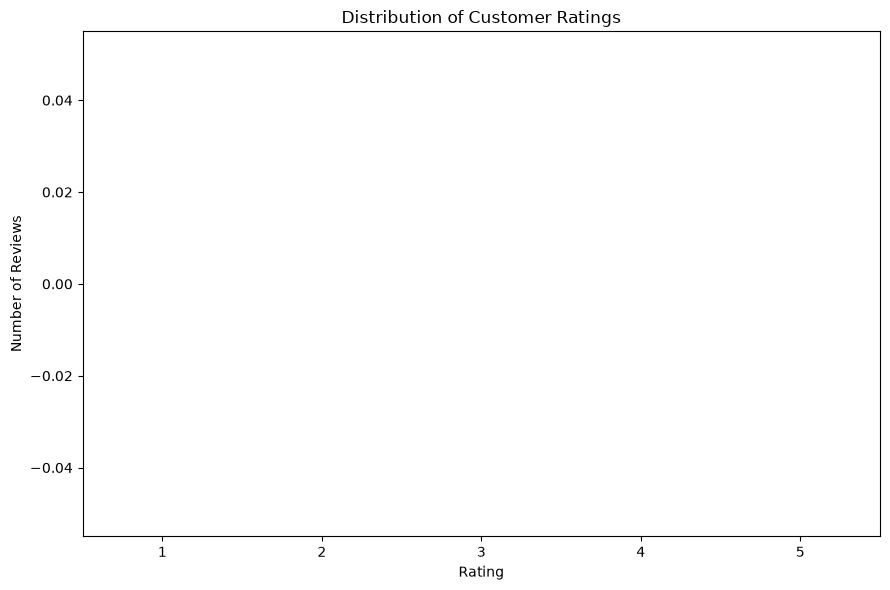

In [90]:
plt.figure(figsize=(9, 6))

sns.countplot(
    data=df_clean,
    x="review/score",
    order=[1, 2, 3, 4, 5]
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.show()

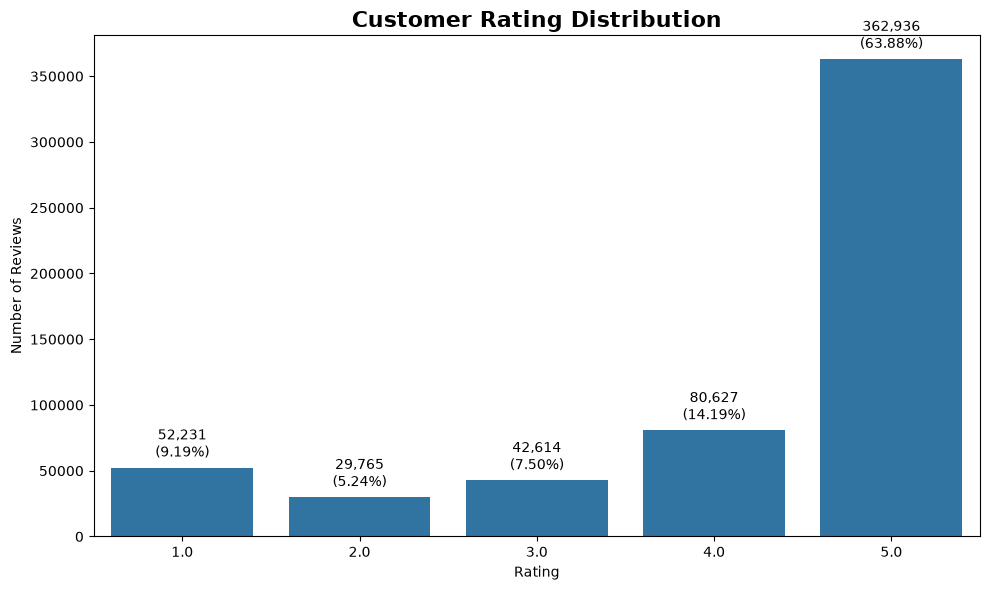

In [91]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=rating_summary.index.astype(str),
    y=rating_summary["Review Count"]
)

plt.title("Customer Rating Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

# Add count and percentage labels above each bar
for i, (count, percentage) in enumerate(
    zip(rating_summary["Review Count"], rating_summary["Percentage"])
):
    ax.text(
        i,
        count + 5000,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [92]:
reviews_by_year = (
    df_clean["review/time"]
    .dt.year
    .value_counts()
    .sort_index()
)

reviews_by_year

review/time
1999         6
2000        32
2001        13
2002        73
2003       132
2004       561
2005      1334
2006      6666
2007     22285
2008     34157
2009     55287
2010     85827
2011    163199
2012    198601
Name: count, dtype: int64

In [93]:
yearly_growth = reviews_by_year.pct_change() * 100

yearly_summary = pd.DataFrame({
    "Review Count": reviews_by_year,
    "Year-over-Year Growth (%)": yearly_growth.round(2)
})

yearly_summary

,Review Count,Year-over-Year Growth (%)
review/time,,
1999,6,NaN
2000,32,433.33
2001,13,-59.38
2002,73,461.54
2003,132,80.82
2004,561,325.00
2005,1334,137.79
2006,6666,399.70
2007,22285,234.31


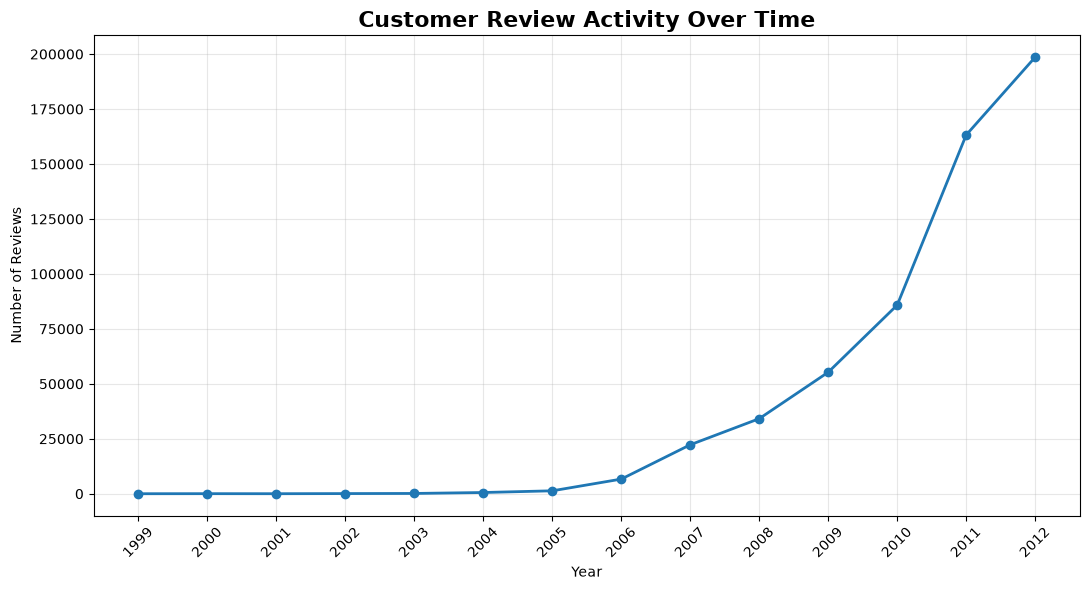

In [94]:
plt.figure(figsize=(11, 6))

plt.plot(
    reviews_by_year.index,
    reviews_by_year.values,
    marker="o",
    linewidth=2
)

plt.title("Customer Review Activity Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.xticks(reviews_by_year.index, rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [95]:
reviews_2007 = reviews_by_year.loc[2007]
reviews_2011 = reviews_by_year.loc[2011]

growth_2007_2011 = (
    (reviews_2011 - reviews_2007)
    / reviews_2007
    * 100
)

print(f"Reviews in 2007: {reviews_2007:,}")
print(f"Reviews in 2011: {reviews_2011:,}")
print(f"Growth from 2007 to 2011: {growth_2007_2011:.2f}%")

Reviews in 2007: 22,285
Reviews in 2011: 163,199
Growth from 2007 to 2011: 632.33%


In [96]:
reviews_by_product = (
    df_clean["product/productId"]
    .value_counts()
)

reviews_by_product.head(10)

product/productId
B007JFMH8M    913
B002QWP89S    631
B0026RQTGE    631
B002QWHJOU    631
B002QWP8H0    631
B003B3OOPA    623
B001EO5Q64    567
B0013NUGDE    564
B007M83302    564
B000VK8AVK    564
Name: count, dtype: int64

In [97]:
top_10_reviews = reviews_by_product.head(10).sum()
total_reviews = len(df_clean)

top_10_percentage = (top_10_reviews / total_reviews) * 100

print(f"Reviews from top 10 products: {top_10_reviews:,}")
print(f"Total reviews: {total_reviews:,}")
print(f"Top 10 share of all reviews: {top_10_percentage:.2f}%")

Reviews from top 10 products: 6,319
Total reviews: 568,173
Top 10 share of all reviews: 1.11%


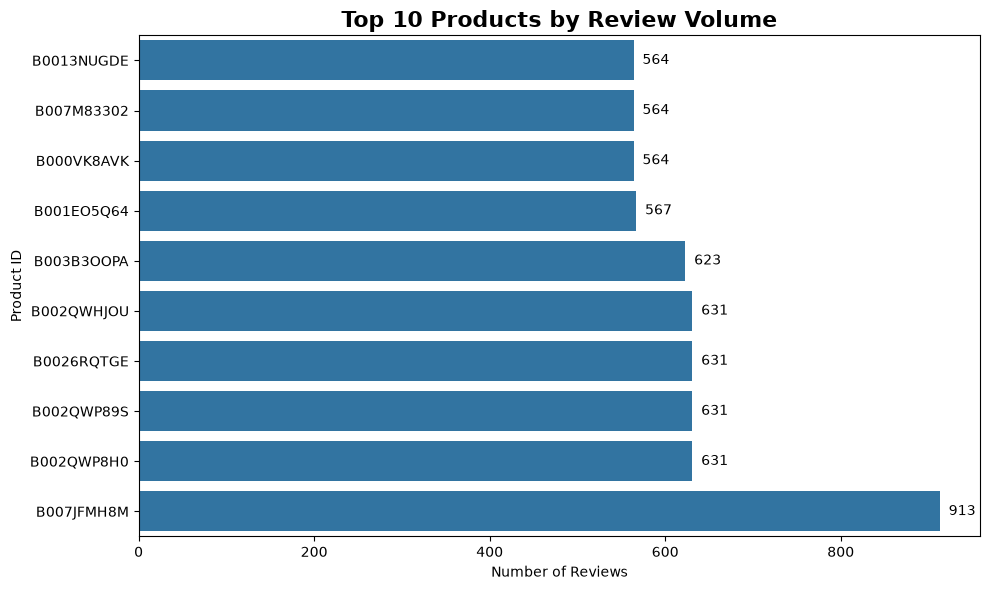

In [98]:
top_10_products = reviews_by_product.head(10).sort_values()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title(
    "Top 10 Products by Review Volume",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Number of Reviews")
plt.ylabel("Product ID")

# Add review-count labels
for i, count in enumerate(top_10_products.values):
    ax.text(
        count + 10,
        i,
        f"{count:,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [99]:
df_clean["review_word_count"] = (
    df_clean["review/text"]
    .str.split()
    .str.len()
)

print("Review word count calculated.")
print(df_clean["review_word_count"].describe())

Review word count calculated.
count    568173.000000
mean         80.223029
std          79.326831
min           3.000000
25%          33.000000
50%          56.000000
75%          98.000000
max        3432.000000
Name: review_word_count, dtype: float64


In [100]:
review_length_by_rating = (
    df_clean
    .groupby("review/score")["review_word_count"]
    .agg(["count", "mean", "median"])
    .round(2)
)

review_length_by_rating

,count,mean,median
review/score,,,
1.0,52231,87.05,62.0
2.0,29765,90.04,67.0
3.0,42614,95.61,70.0
4.0,80627,91.37,65.0
5.0,362936,74.15,52.0


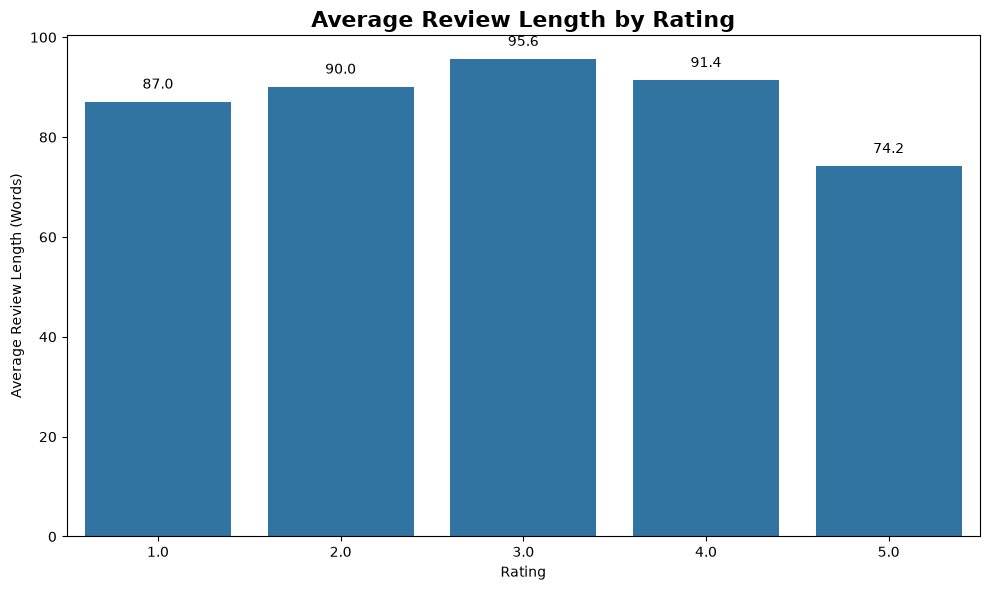

In [101]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=review_length_by_rating.index.astype(str),
    y=review_length_by_rating["mean"]
)

plt.title(
    "Average Review Length by Rating",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Rating")
plt.ylabel("Average Review Length (Words)")

# Add value labels
for i, value in enumerate(review_length_by_rating["mean"]):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [102]:
df_clean["helpfulness_rate"] = (
    df_clean["helpful_votes"]
    / df_clean["total_votes"]
)

print("Helpfulness rate calculated.")
print(df_clean["helpfulness_rate"].describe())

Helpfulness rate calculated.
count    298321.000000
mean          0.777001
std           0.346263
min           0.000000
25%           0.600000
50%           1.000000
75%           1.000000
max           1.000000
Name: helpfulness_rate, dtype: float64


In [103]:
helpfulness_data = df_clean[
    ["review_word_count", "helpfulness_rate"]
].dropna()

correlation = helpfulness_data["review_word_count"].corr(
    helpfulness_data["helpfulness_rate"]
)

print(f"Pearson correlation: {correlation:.4f}")

Pearson correlation: 0.0409


In [104]:
vote_count_summary = (
    df_clean["total_votes"]
    .dropna()
    .describe()
)

vote_count_summary

count    568171.000000
mean          2.229243
std           8.291399
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max         923.000000
Name: total_votes, dtype: float64

In [105]:
vote_bins = [-1, 0, 2, 5, 10, 25, float("inf")]
vote_labels = [
    "0 votes",
    "1–2 votes",
    "3–5 votes",
    "6–10 votes",
    "11–25 votes",
    "26+ votes"
]

df_clean["vote_group"] = pd.cut(
    df_clean["total_votes"],
    bins=vote_bins,
    labels=vote_labels
)

helpfulness_by_votes = (
    df_clean
    .groupby("vote_group", observed=False)["helpfulness_rate"]
    .agg(["count", "mean", "median"])
    .round(3)
)

helpfulness_by_votes

,count,mean,median
vote_group,,,
0 votes,0,NaN,NaN
1–2 votes,174195,0.788,1.000
3–5 votes,71500,0.764,1.000
6–10 votes,31180,0.753,0.857
11–25 votes,16550,0.751,0.889
26+ votes,4896,0.814,0.927


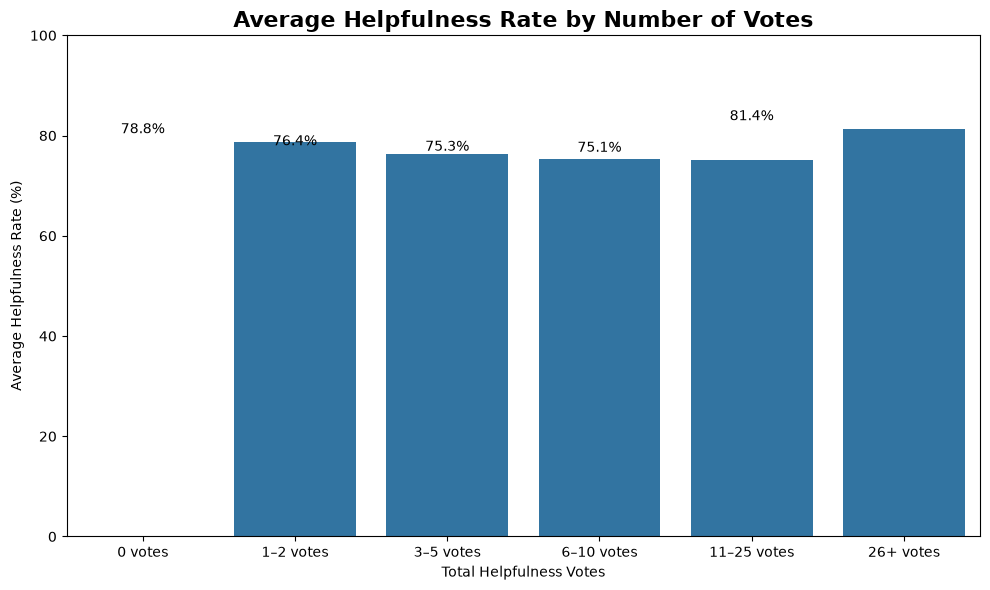

In [106]:
helpfulness_plot_data = helpfulness_by_votes.dropna(
    subset=["mean"]
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=helpfulness_plot_data.index,
    y=helpfulness_plot_data["mean"] * 100
)

plt.title(
    "Average Helpfulness Rate by Number of Votes",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Total Helpfulness Votes")
plt.ylabel("Average Helpfulness Rate (%)")

# Add percentage labels
for i, value in enumerate(helpfulness_plot_data["mean"] * 100):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [107]:
Q1 = df_clean["review_word_count"].quantile(0.25)
Q3 = df_clean["review_word_count"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + (1.5 * IQR)

long_review_count = (
    df_clean["review_word_count"] > upper_bound
).sum()

long_review_percentage = (
    long_review_count / len(df_clean)
) * 100

print(f"Q1: {Q1:.2f} words")
print(f"Q3: {Q3:.2f} words")
print(f"IQR: {IQR:.2f} words")
print(f"Upper outlier threshold: {upper_bound:.2f} words")
print(f"Reviews above threshold: {long_review_count:,}")
print(f"Percentage of reviews above threshold: {long_review_percentage:.2f}%")

Q1: 33.00 words
Q3: 98.00 words
IQR: 65.00 words
Upper outlier threshold: 195.50 words
Reviews above threshold: 37,094
Percentage of reviews above threshold: 6.53%


In [108]:
short_review_summary = (
    df_clean["review_word_count"]
    .value_counts()
    .sort_index()
    .head(10)
)

short_review_summary

review_word_count
3       2
4       1
5       1
6       8
7      51
8      10
9      26
10     50
11    106
12    149
Name: count, dtype: int64

In [109]:
short_review_summary = (
    df_clean["review_word_count"]
    .value_counts()
    .sort_index()
    .head(10)
)

short_review_summary

review_word_count
3       2
4       1
5       1
6       8
7      51
8      10
9      26
10     50
11    106
12    149
Name: count, dtype: int64

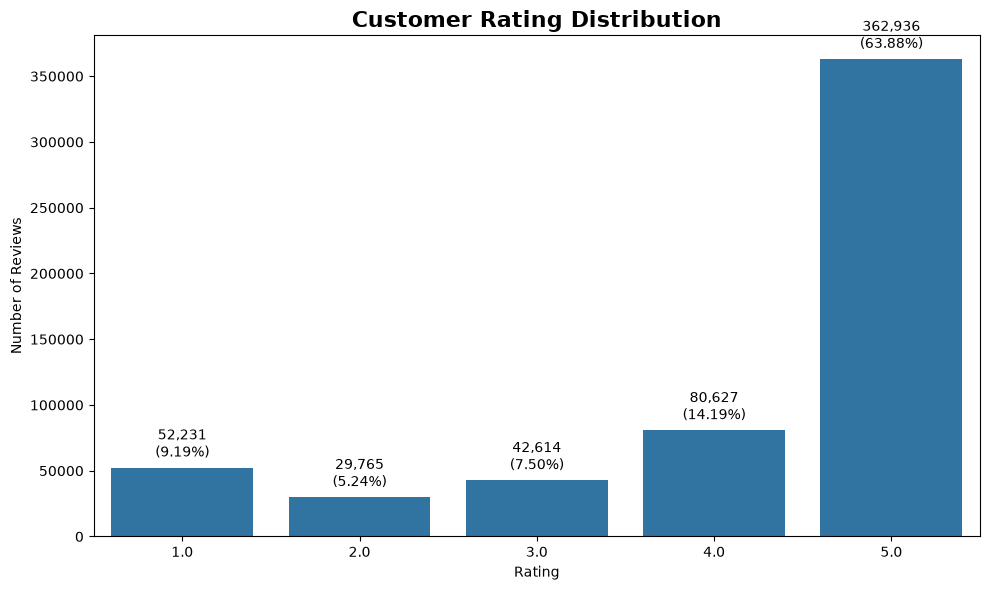

In [110]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=rating_summary.index.astype(str),
    y=rating_summary["Review Count"]
)

plt.title(
    "Customer Rating Distribution",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

for i, (count, percentage) in enumerate(
    zip(
        rating_summary["Review Count"],
        rating_summary["Percentage"]
    )
):
    ax.text(
        i,
        count + 5000,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

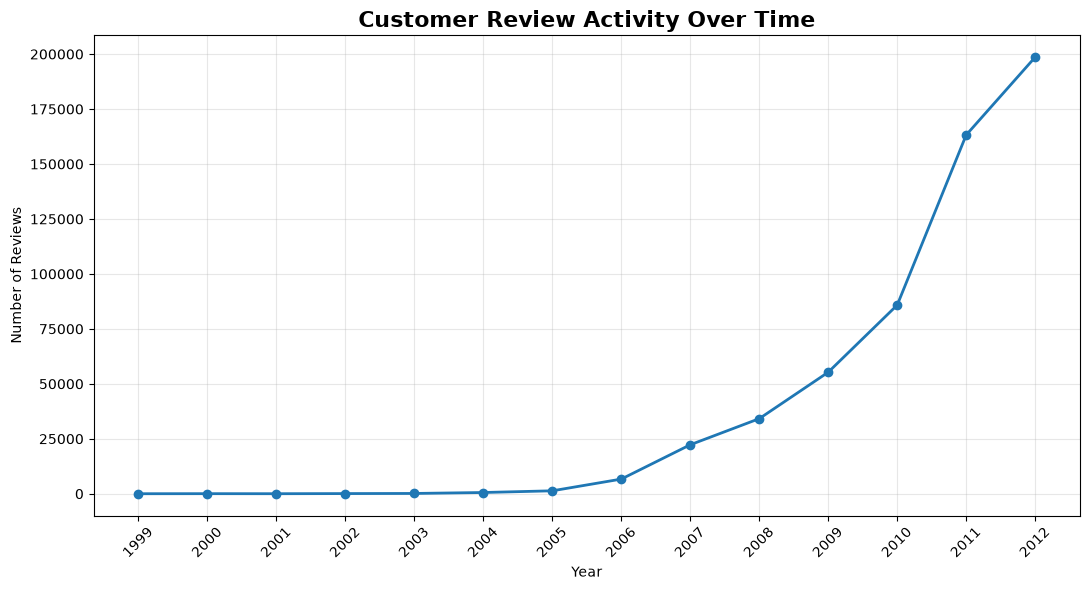

In [111]:
plt.figure(figsize=(11, 6))

plt.plot(
    reviews_by_year.index,
    reviews_by_year.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Customer Review Activity Over Time",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Number of Reviews")

plt.xticks(
    reviews_by_year.index,
    rotation=45
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

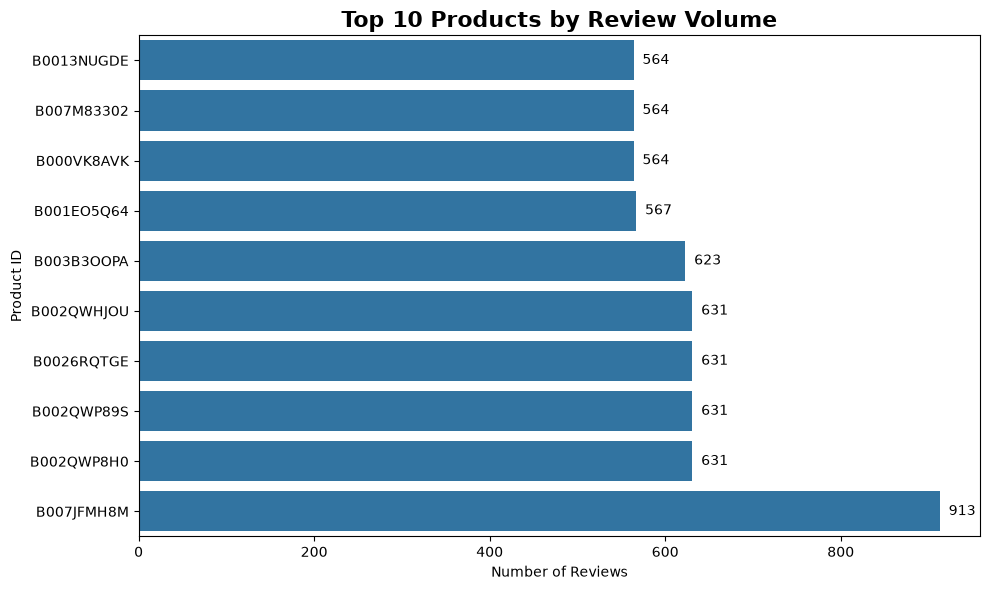

In [112]:
top_10_products = (
    reviews_by_product
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title(
    "Top 10 Products by Review Volume",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Reviews")
plt.ylabel("Product ID")

for i, count in enumerate(top_10_products.values):
    ax.text(
        count + 10,
        i,
        f"{count:,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

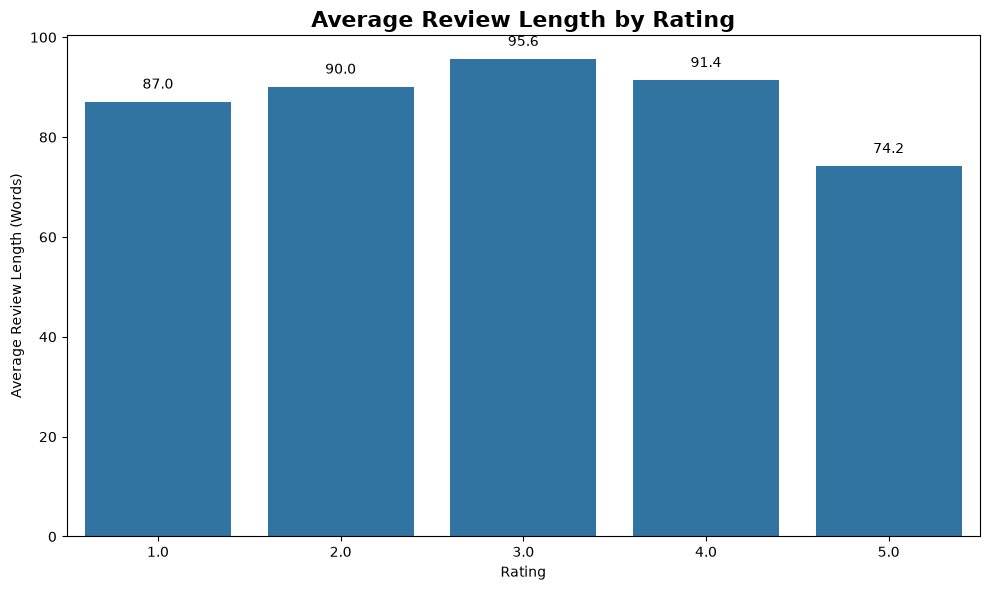

In [113]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=review_length_by_rating.index.astype(str),
    y=review_length_by_rating["mean"]
)

plt.title(
    "Average Review Length by Rating",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Rating")
plt.ylabel("Average Review Length (Words)")

for i, value in enumerate(review_length_by_rating["mean"]):
    ax.text(
        i,
        value + 2,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

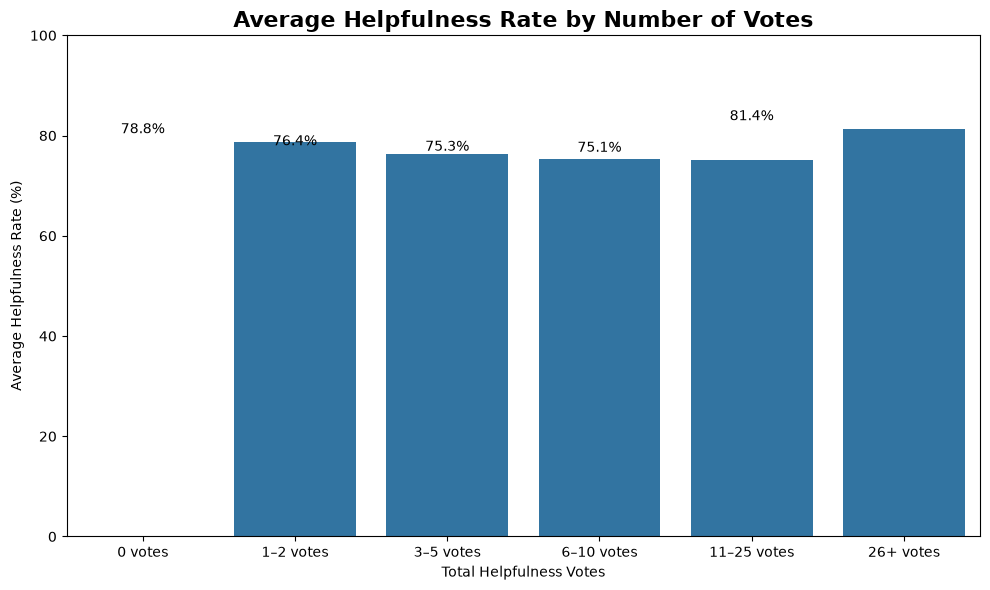

In [114]:
helpfulness_plot_data = (
    helpfulness_by_votes
    .dropna(subset=["mean"])
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=helpfulness_plot_data.index,
    y=helpfulness_plot_data["mean"] * 100
)

plt.title(
    "Average Helpfulness Rate by Number of Votes",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Helpfulness Votes")
plt.ylabel("Average Helpfulness Rate (%)")

for i, value in enumerate(
    helpfulness_plot_data["mean"] * 100
):
    ax.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

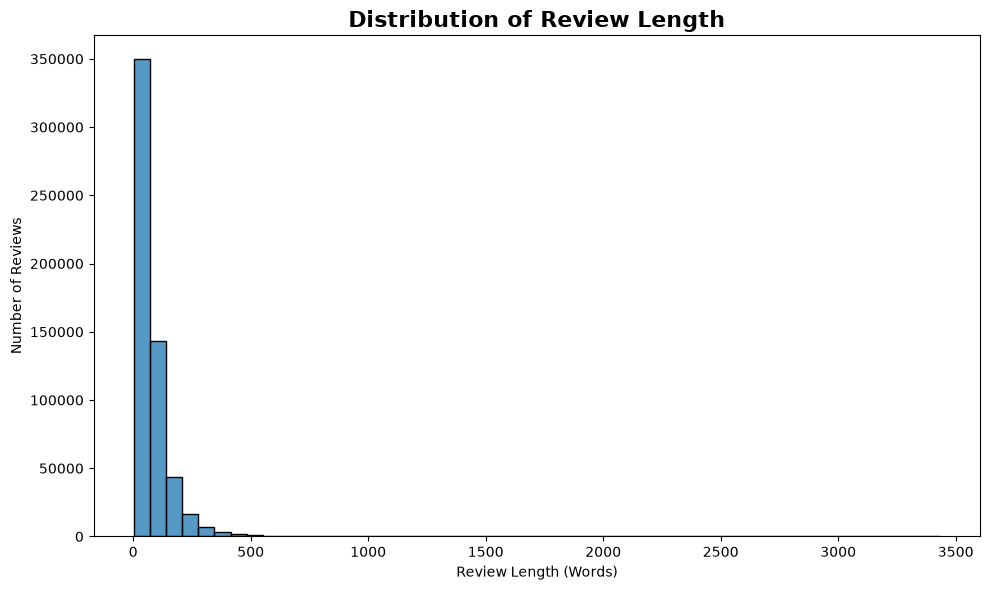

In [115]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["review_word_count"],
    bins=50
)

plt.title(
    "Distribution of Review Length",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Review Length (Words)")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()